# Cuaderno 09 Ensamblaje de Secuencias

**Curso:** Bioinformática  
**Tema:** Grafo de De Bruijn y Camino Euleriano  
**Repositorio:** `bio-notebooks`

## Competencias

### Del curso
Conoce, comprende y aplica los conceptos fundamentales de la Bioinformática.

### Del laboratorio
Implementar un grafo de De Bruijn para reconstruir secuencias biológicas a partir
de fragmentos de ADN, aplicando estructuras de datos y algoritmos de teoría de grafos.


## 1. Marco Teórico

### 1.1 Ensamblaje de secuencias

El ensamblaje de secuencias reconstruye una secuencia de ADN original a partir de
múltiples fragmentos cortos (**reads**) obtenidos por secuenciación. Las tecnologías
actuales no pueden leer moléculas largas de ADN en una sola operación, por lo que
se generan miles de fragmentos cortos que deben ensamblarse computacionalmente.

### 1.2 Grafo de De Bruijn

Dado un conjunto de reads y un valor $k$:

1. Se generan todos los **k-mers** (subcadenas de longitud $k$) de los reads.
2. Cada k-mer se divide en:
   - **Prefijo**: primeros $k-1$ caracteres → nodo origen
   - **Sufijo**: últimos $k-1$ caracteres → nodo destino
3. Cada k-mer se representa como una **arista** que conecta prefijo → sufijo.

**Ejemplo** (teoría): `ATGC` con $k=4$:
- Prefijo: `ATG` → Sufijo: `TGC`
- Arista: `ATG → TGC`

### 1.3 Camino Euleriano

El ensamblaje consiste en encontrar un **camino Euleriano**: un recorrido que
atraviesa **cada arista exactamente una vez**. La secuencia reconstruida se obtiene
concatenando el primer nodo con el último carácter de cada nodo visitado.

**Condición de existencia:**
- Circuito Euleriano: todos los nodos tienen grado entrada = grado salida.
- Camino Euleriano: exactamente un nodo con `out - in = 1` (inicio) y uno con `in - out = 1` (fin).

**Algoritmo de Hierholzer** (complejidad $O(E)$):
1. Partir del nodo inicial (el de `out > in` si existe).
2. Seguir aristas hasta no poder continuar → apilar el nodo.
3. Retroceder buscando nodos con aristas no visitadas → extender el circuito.

### 1.4 Influencia de k

| k pequeño | k grande |
|-----------|----------|
| Más conexiones, más ambigüedades | Menos ambigüedades |
| Sensible a repeticiones | Requiere mayor cobertura |
| Grafo más denso | Grafo más disperso |
| Posibles ensamblajes erróneos | Posibles grafos desconectados |


## 2. Implementación

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import os

os.makedirs("data", exist_ok=True)


# Grafo de De Bruijn
class DeBruijnGraph:
    """
    Grafo De Bruijn construido a partir de un conjunto de reads y un valor k.

    Atributos
    ---------
    k        : longitud de los k-mers
    grafo    : dict {nodo: [vecinos]}  (lista de adyacencia)
    kmers    : lista de todos los k-mers generados
    in_deg   : grado de entrada por nodo
    out_deg  : grado de salida por nodo
    """

    def __init__(self, reads: list[str], k: int):
        self.k      = k
        self.grafo  = defaultdict(list)
        self.kmers  = []
        self.in_deg  = defaultdict(int)
        self.out_deg = defaultdict(int)
        self._construir(reads)

    def _construir(self, reads: list[str]):
        for read in reads:
            for i in range(len(read) - self.k + 1):
                km  = read[i:i+self.k]
                pre = km[:-1]
                suf = km[1:]
                self.grafo[pre].append(suf)
                self.kmers.append(km)
                self.out_deg[pre] += 1
                self.in_deg[suf]  += 1

    @property
    def nodos(self) -> set:
        return set(self.grafo.keys()) | {v for vs in self.grafo.values() for v in vs}

    @property
    def num_aristas(self) -> int:
        return sum(len(v) for v in self.grafo.values())

    def nodo_inicio(self) -> str:
        """Nodo con out_deg - in_deg = 1 (inicio del camino Euleriano)."""
        for n in self.nodos:
            if self.out_deg[n] - self.in_deg[n] == 1:
                return n
        return next(iter(self.grafo))

    def es_euleriano(self) -> tuple[bool, str]:
        """Verifica si existe camino o circuito Euleriano."""
        diferencias = {n: self.out_deg[n] - self.in_deg[n] for n in self.nodos}
        inicio = sum(1 for d in diferencias.values() if d == 1)
        fin    = sum(1 for d in diferencias.values() if d == -1)
        otros  = sum(1 for d in diferencias.values() if abs(d) > 1)
        if otros > 0:
            return False, "No Euleriano (hay nodos con |out-in| > 1)"
        if inicio == 0 and fin == 0:
            return True, "Circuito Euleriano (todos los grados balanceados)"
        if inicio == 1 and fin == 1:
            return True, "Camino Euleriano (un nodo inicio y uno fin)"
        return False, f"No Euleriano (inicio={inicio}, fin={fin})"

    def resumen(self):
        es_e, tipo = self.es_euleriano()
        print(f"  k          : {self.k}")
        print(f"  k-mers     : {len(self.kmers)}")
        print(f"  Nodos      : {len(self.nodos)}")
        print(f"  Aristas    : {self.num_aristas}")
        print(f"  Euleriano  : {es_e}  ({tipo})")


print("DeBruijnGraph implementado.")


DeBruijnGraph implementado.


In [2]:
# Camino Euleriano (Hierholzer)
def camino_euleriano(dbg: DeBruijnGraph) -> list[str]:
    """
    Algoritmo de Hierholzer para encontrar el camino Euleriaon
    Complejidad: O(E) donde E = número de aristas
    """
    # Copia del grafo para no modificar el original
    g = {u: list(vs) for u, vs in dbg.grafo.items()}

    inicio = dbg.nodo_inicio()
    pila   = [inicio]
    camino = []

    while pila:
        v = pila[-1]
        if g.get(v):
            pila.append(g[v].pop(0))
        else:
            camino.append(pila.pop())

    return list(reversed(camino))


def reconstruir_secuencia(camino: list[str]) -> str:
    """Reconstruimoss la secuencia a partir del camino Euleriano"""
    if not camino:
        return ""
    seq = camino[0]
    for nodo in camino[1:]:
        seq += nodo[-1]
    return seq


print("Hierholzer y reconstrucción listos.")


Hierholzer y reconstrucción listos.


## 3. Actividad Ejemplo del laboratorio

Secuencia original: `ATGCGATGAC`, $k = 4$.

Verificamos que el grafo generado coincide exactamente con el del enunciado.


In [3]:
seq_original = "ATGCGATGAC"
k = 4

dbg = DeBruijnGraph([seq_original], k)

print(f"Secuencia: {seq_original}  k={k}")
print()
print("K-mers generados:")
for km in dbg.kmers:
    print(f"  {km}  ->  prefijo={km[:-1]}  sufijo={km[1:]}")

print()
print("Lista de adyacencia (grafo):")
for nodo, vecinos in sorted(dbg.grafo.items()):
    print(f"  {nodo} -> {', '.join(vecinos)}")

print()
print("Resumen del grafo:")
dbg.resumen()

print()
camino = camino_euleriano(dbg)
print(f"Camino Euleriano:")
print(f"  {' -> '.join(camino)}")

reconstruida = reconstruir_secuencia(camino)
print()
print(f"Secuencia reconstruida : {reconstruida}")
print(f"Secuencia original     : {seq_original}")
print(f"Coinciden              : {reconstruida == seq_original}")


Secuencia: ATGCGATGAC  k=4

K-mers generados:
  ATGC  ->  prefijo=ATG  sufijo=TGC
  TGCG  ->  prefijo=TGC  sufijo=GCG
  GCGA  ->  prefijo=GCG  sufijo=CGA
  CGAT  ->  prefijo=CGA  sufijo=GAT
  GATG  ->  prefijo=GAT  sufijo=ATG
  ATGA  ->  prefijo=ATG  sufijo=TGA
  TGAC  ->  prefijo=TGA  sufijo=GAC

Lista de adyacencia (grafo):
  ATG -> TGC, TGA
  CGA -> GAT
  GAT -> ATG
  GCG -> CGA
  TGA -> GAC
  TGC -> GCG

Resumen del grafo:
  k          : 4
  k-mers     : 7
  Nodos      : 7
  Aristas    : 7
  Euleriano  : True  (Camino Euleriano (un nodo inicio y uno fin))

Camino Euleriano:
  ATG -> TGC -> GCG -> CGA -> GAT -> ATG -> TGA -> GAC

Secuencia reconstruida : ATGCGATGAC
Secuencia original     : ATGCGATGAC
Coinciden              : True


## 4. Visualización del grafo de De Bruijn

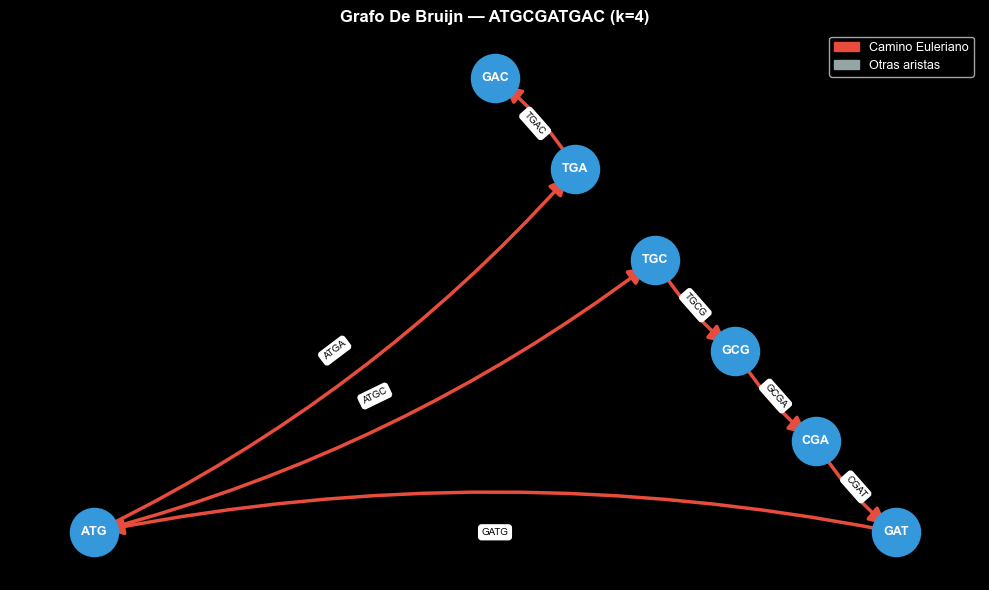

In [4]:
def visualizar_grafo(dbg: DeBruijnGraph, camino: list[str] = None,
                     titulo: str = "Grafo de De Bruijn", fname: str = None):
    """
    Visualiza el grafo de De Bruijn con networkx.
    Si se proporciona el camino Euleriano, resalta las aristas en orden.
    """
    G = nx.MultiDiGraph()
    for u, vs in dbg.grafo.items():
        for v in vs:
            G.add_edge(u, v)

    fig, ax = plt.subplots(figsize=(10, 6))
    try:
        pos = nx.planar_layout(G)
    except nx.NetworkXException:
        pos = nx.spring_layout(G, seed=42, k=2)

    # Aristas del camino Euleriano resaltadas
    aristas_camino = []
    if camino and len(camino) > 1:
        for i in range(len(camino)-1):
            aristas_camino.append((camino[i], camino[i+1]))

    aristas_normales = [(u,v) for u,v in G.edges() if (u,v) not in aristas_camino]

    nx.draw_networkx_nodes(G, pos, node_color='#3498db', node_size=1200, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=aristas_normales,
                           edge_color='#95a5a6', arrows=True,
                           arrowsize=20, width=1.5,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    if aristas_camino:
        nx.draw_networkx_edges(G, pos, edgelist=aristas_camino,
                               edge_color='#e74c3c', arrows=True,
                               arrowsize=25, width=2.5,
                               connectionstyle='arc3,rad=0.1', ax=ax)

    # Etiquetas de aristas (k-mers)
    edge_labels = {}
    for u, vs in dbg.grafo.items():
        for v in vs:
            km = u + v[-1]
            edge_labels[(u,v)] = km
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=7, ax=ax)

    leyenda = [
        mpatches.Patch(color='#e74c3c', label='Camino Euleriano'),
        mpatches.Patch(color='#95a5a6', label='Otras aristas'),
    ]
    ax.legend(handles=leyenda, loc='upper right', fontsize=9)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    if fname:
        plt.savefig(f"data/{fname}", dpi=150, bbox_inches='tight')
    plt.show()


visualizar_grafo(dbg, camino,
    titulo=f"Grafo De Bruijn — ATGCGATGAC (k={k})",
    fname="fig_debruijn_ejemplo.png")


## 5. Experimentación con distintos valores de k

Probamos $k = 3, 4, 5, 6$ sobre la secuencia `ATGCGATGAC` y respondemos
las preguntas del laboratorio.


In [5]:
seq_original = "ATGCGATGAC"
resultados = []

print(f"Secuencia: {seq_original}")
print(f"{'k':>4} {'k-mers':>8} {'nodos':>7} {'aristas':>9} {'Euleriano':>12}  Reconstruida")
print("-" * 75)

for k in [3, 4, 5, 6]:
    dbg  = DeBruijnGraph([seq_original], k)
    es_e, tipo = dbg.es_euleriano()
    camino = camino_euleriano(dbg)
    rec    = reconstruir_secuencia(camino)
    ok     = "✓" if rec == seq_original else "✗"
    print(f"  {k:>2}  {len(dbg.kmers):>8}  {len(dbg.nodos):>7}  {dbg.num_aristas:>9}"
          f"  {'Sí' if es_e else 'No':>12}  {rec}  {ok}")
    resultados.append({"k":k,"kmers":len(dbg.kmers),"nodos":len(dbg.nodos),
                       "aristas":dbg.num_aristas,"rec":rec})

print()
print("Respuestas a las preguntas del laboratorio:")
print()
print("  ¿Cómo cambia el número de nodos?")
print("    Al aumentar k los nodos (k-1-mers) se hacen más específicos.")
print("    Con k=3 hay 6 nodos; con k=6 también 6, pero son cadenas más largas.")
print("    En general a mayor k, menos nodos comparten el mismo prefijo/sufijo.")
print()
print("  ¿Cómo cambia el número de aristas?")
print("    El número de aristas = número de k-mers únicos en la secuencia.")
print("    A mayor k, hay menos k-mers posibles en una secuencia corta → menos aristas.")
print()
print("  ¿Qué sucede cuando k es muy pequeño?")
print("    Con k=3: el nodo 'TG' tiene dos sucesores (GC y GA) → bifurcación.")
print("    El grafo es más denso y hay ambigüedades en el camino Euleriano.")
print("    En secuencias reales esto genera ensamblajes erróneos o múltiples contigs.")
print()
print("  ¿Qué sucede cuando k es muy grande?")
print("    Con k=6: el grafo es casi lineal, sin bifurcaciones.")
print("    Pero si los reads son cortos, muchos k-mers no se generan → grafo desconectado.")
print("    Requiere mayor cobertura para mantener la conectividad.")


Secuencia: ATGCGATGAC
   k   k-mers   nodos   aristas    Euleriano  Reconstruida
---------------------------------------------------------------------------
   3         8        6          8            Sí  ATGCGATGAC  ✓
   4         7        7          7            Sí  ATGCGATGAC  ✓
   5         6        7          6            Sí  ATGCGATGAC  ✓
   6         5        6          5            Sí  ATGCGATGAC  ✓

Respuestas a las preguntas del laboratorio:

  ¿Cómo cambia el número de nodos?
    Al aumentar k los nodos (k-1-mers) se hacen más específicos.
    Con k=3 hay 6 nodos; con k=6 también 6, pero son cadenas más largas.
    En general a mayor k, menos nodos comparten el mismo prefijo/sufijo.

  ¿Cómo cambia el número de aristas?
    El número de aristas = número de k-mers únicos en la secuencia.
    A mayor k, hay menos k-mers posibles en una secuencia corta → menos aristas.

  ¿Qué sucede cuando k es muy pequeño?
    Con k=3: el nodo 'TG' tiene dos sucesores (GC y GA) → bifurcació

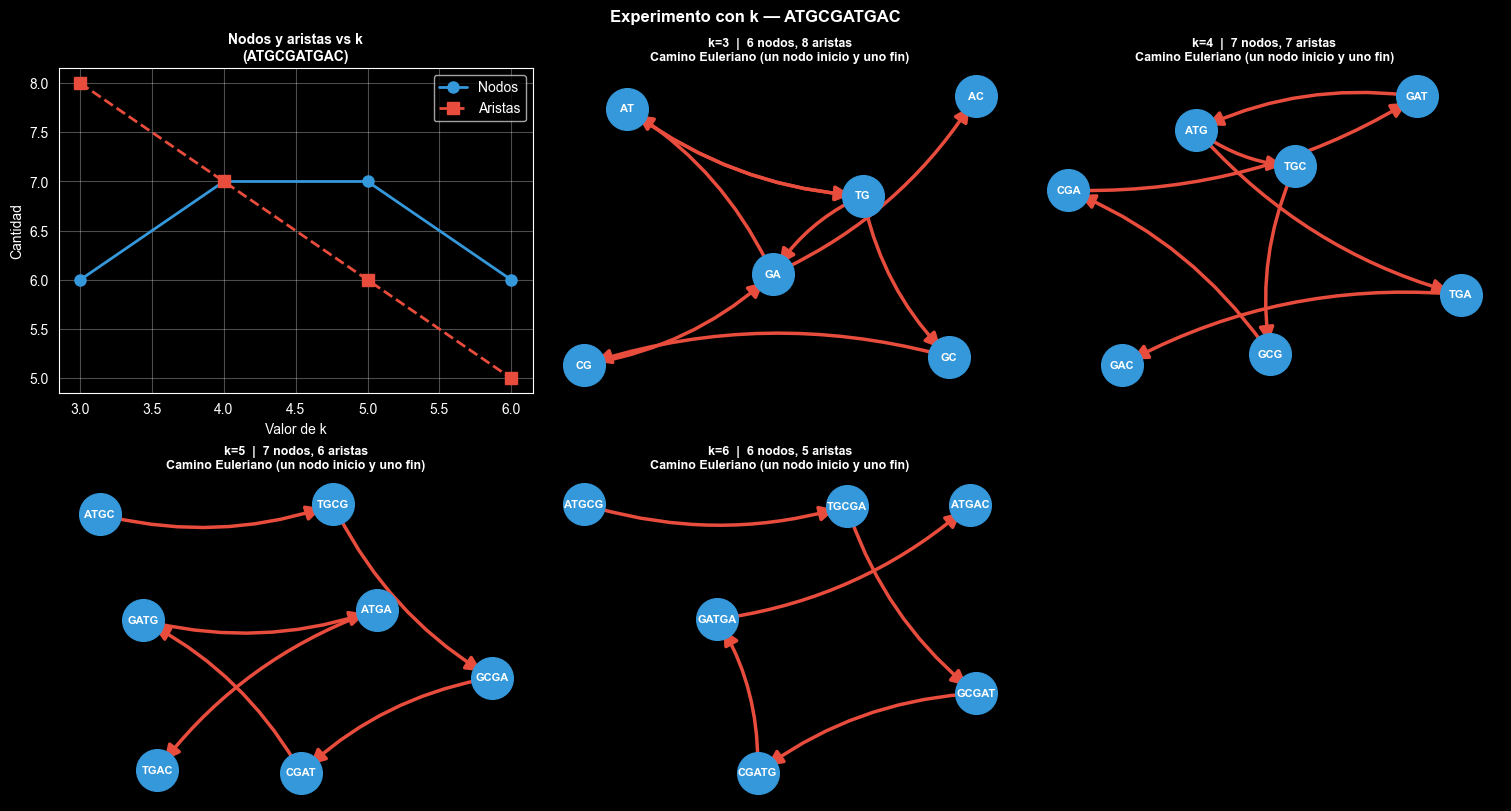

Figura guardada.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout='constrained')

# Subplot [0,0]: gráfica nodos/aristas vs k
ax_plot = axes[0, 0]
ks = [r['k'] for r in resultados]
ax_plot.plot(ks, [r['nodos'] for r in resultados], 'o-', color='#3498db',
             lw=2, markersize=8, label='Nodos')
ax_plot.plot(ks, [r['aristas'] for r in resultados], 's--', color='#e74c3c',
             lw=2, markersize=8, label='Aristas')
ax_plot.set_xlabel("Valor de k", fontsize=10)
ax_plot.set_ylabel("Cantidad", fontsize=10)
ax_plot.set_title("Nodos y aristas vs k\n(ATGCGATGAC)", fontsize=10, fontweight='bold')
ax_plot.legend(); ax_plot.grid(alpha=0.3)

# Subplots [0,1], [0,2], [1,0], [1,1]: un grafo por cada k
posiciones_ax = [axes[0,1], axes[0,2], axes[1,0], axes[1,1]]
axes[1, 2].axis('off')  # celda vacía

for ax, k in zip(posiciones_ax, [3, 4, 5, 6]):
    dbg_k  = DeBruijnGraph([seq_original], k=k)
    camino_k = camino_euleriano(dbg_k)
    Gk = nx.MultiDiGraph()
    for u, vs in dbg_k.grafo.items():
        for v in vs: Gk.add_edge(u, v)

    pos_k = nx.spring_layout(Gk, seed=7, k=2)
    aristas_c = list(zip(camino_k[:-1], camino_k[1:]))
    aristas_o = [(u, v) for u, v in Gk.edges() if (u, v) not in aristas_c]

    nx.draw_networkx_nodes(Gk, pos_k, node_color='#3498db', node_size=900, ax=ax)
    nx.draw_networkx_labels(Gk, pos_k, font_size=8, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(Gk, pos_k, edgelist=aristas_o, edge_color='#95a5a6',
                           arrows=True, arrowsize=18, width=1.5,
                           connectionstyle='arc3,rad=0.15', ax=ax)
    nx.draw_networkx_edges(Gk, pos_k, edgelist=aristas_c, edge_color='#e74c3c',
                           arrows=True, arrowsize=22, width=2.5,
                           connectionstyle='arc3,rad=0.15', ax=ax)
    es_e, tipo = dbg_k.es_euleriano()
    ax.set_title(f"k={k}  |  {len(dbg_k.nodos)} nodos, {dbg_k.num_aristas} aristas\n{tipo}",
                 fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle("Experimento con k — ATGCGATGAC", fontsize=12, fontweight='bold')
plt.savefig("data/fig_experimento_k.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada.")

## 6. Ejercicio 1 Reconstrucción desde fragmentos reales

Dado el conjunto de 9 fragmentos de ADN con solapamientos, reconstruimos
la secuencia original usando k = 5, 7 y 9.


In [7]:
fragmentos = [
    "ATGGCAGATTAGTGCAATGG",
    "GGAGGCTTCGGAAACTGACT",
    "AGATTAGTGCAATGGCTTCA",
    "ATGGCTTCAATTTTAGGTTC",
    "GTTCTATGCTTGGAGGCTTC",
    "TTCAATTTTAGGTTCTATGC",
    "TTTAGGTTCTATGCTTGGAG",
    "ATGCTTGGAGGCTTCGGAAA",
    "GTGCAATGGCTTCAATTTTA",
]

# Secuencia de referencia (ensamblaje manual por solapamiento)
SEQ_REF = "ATGGCAGATTAGTGCAATGGCTTCAATTTTAGGTTCTATGCTTGGAGGCTTCGGAAACTGACT"

print("Fragmentos de entrada:")
for i, f in enumerate(fragmentos, 1):
    print(f"  F{i:>2}: {f}  ({len(f)} nt)")
print(f"\nSecuencia de referencia ({len(SEQ_REF)} nt):")
print(f"  {SEQ_REF}")
print()
print(f"{'k':>4} {'nodos':>7} {'aristas':>9} {'len_rec':>9}  Reconstruida (primeros 63 nt)")
print("-" * 80)

for k in [5, 7, 9]:
    dbg    = DeBruijnGraph(fragmentos, k)
    es_e, tipo = dbg.es_euleriano()
    camino = camino_euleriano(dbg)
    rec    = reconstruir_secuencia(camino)
    # Verificar si la referencia está contenida
    contiene = SEQ_REF in rec
    print(f"  {k:>2}  {len(dbg.nodos):>7}  {dbg.num_aristas:>9}  {len(rec):>9}"
          f"  {rec[:63]}...")
    print(f"      Euleriano: {tipo}")
    print(f"      Contiene ref: {'✓' if contiene else '✗'}  ({len(rec)} nt reconstruidos)")
    print()


Fragmentos de entrada:
  F 1: ATGGCAGATTAGTGCAATGG  (20 nt)
  F 2: GGAGGCTTCGGAAACTGACT  (20 nt)
  F 3: AGATTAGTGCAATGGCTTCA  (20 nt)
  F 4: ATGGCTTCAATTTTAGGTTC  (20 nt)
  F 5: GTTCTATGCTTGGAGGCTTC  (20 nt)
  F 6: TTCAATTTTAGGTTCTATGC  (20 nt)
  F 7: TTTAGGTTCTATGCTTGGAG  (20 nt)
  F 8: ATGCTTGGAGGCTTCGGAAA  (20 nt)
  F 9: GTGCAATGGCTTCAATTTTA  (20 nt)

Secuencia de referencia (63 nt):
  ATGGCAGATTAGTGCAATGGCTTCAATTTTAGGTTCTATGCTTGGAGGCTTCGGAAACTGACT

   k   nodos   aristas   len_rec  Reconstruida (primeros 63 nt)
--------------------------------------------------------------------------------
   5       52        144        148  AGATTAGTGCAATGGCAGATTAGTGCAAAATTGGCTTCAATTTTAGGTTCTATGCTTCAATTT...
      Euleriano: No Euleriano (inicio=3, fin=3)
      Contiene ref: ✗  (148 nt reconstruidos)

   7       57        126        115  GTGCAATTTGGGGGGCCTTTTTCCCAATTTTAGGTTCTATGCTTGGAGGCTTCAATTTTTTTA...
      Euleriano: No Euleriano (inicio=9, fin=9)
      Contiene ref: ✗  (115 nt reconstruidos)



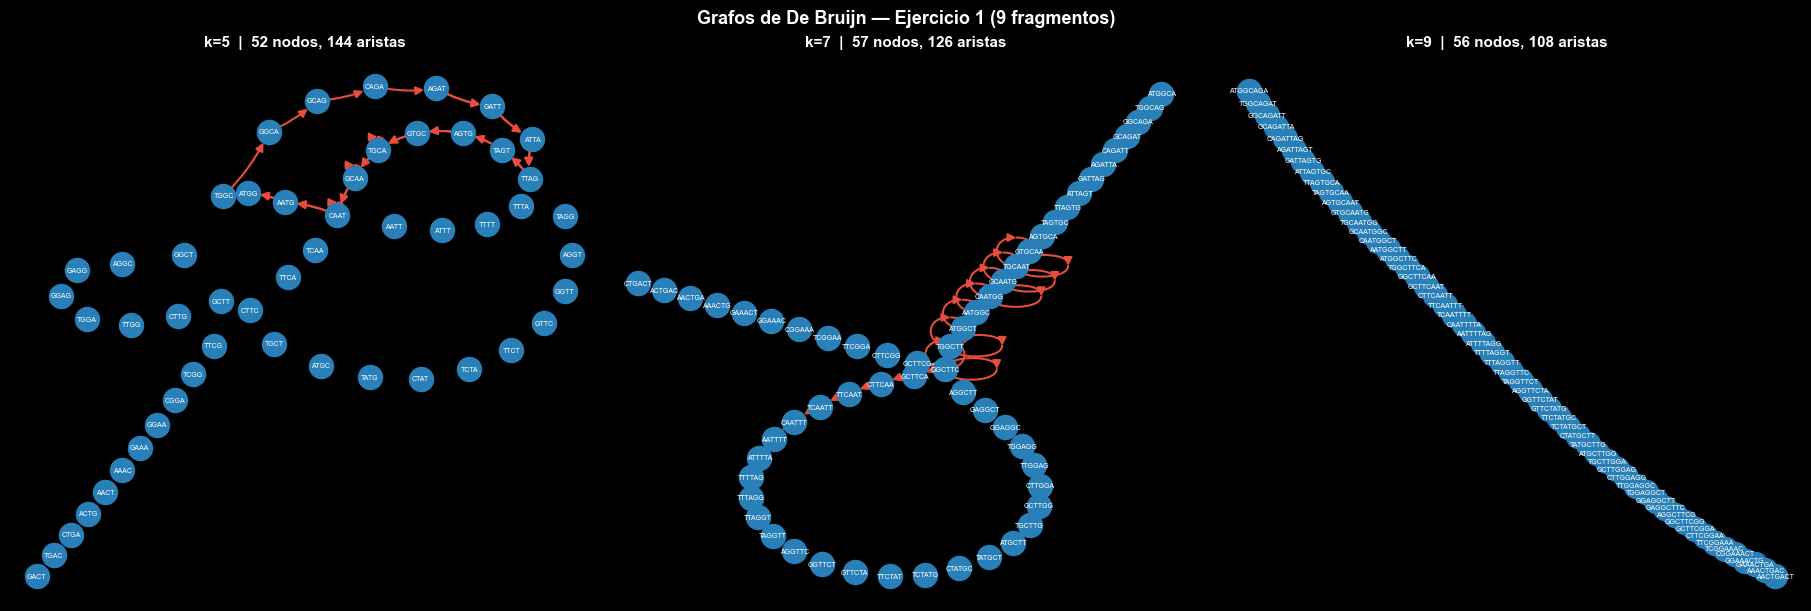

Figura guardada en data/fig_debruijn_ej1.png


In [8]:
# Visualizar los grafos para k=5, 7, 9
fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained')

for ax, k in zip(axes, [5, 7, 9]):
    dbg    = DeBruijnGraph(fragmentos, k)
    camino = camino_euleriano(dbg)
    G      = nx.MultiDiGraph()
    for u, vs in dbg.grafo.items():
        for v in vs: G.add_edge(u, v)

    try:
        pos = nx.kamada_kawai_layout(G)
    except Exception:
        pos = nx.spring_layout(G, seed=42)

    aristas_c = list(zip(camino[:-1], camino[1:]))
    aristas_o = [(u,v) for u,v in G.edges() if (u,v) not in aristas_c]

    nx.draw_networkx_nodes(G, pos, node_color='#2980b9', node_size=300, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=5, font_color='white', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=aristas_o, edge_color='#bdc3c7',
                           arrows=True, arrowsize=10, width=0.8,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=aristas_c[:30], edge_color='#e74c3c',
                           arrows=True, arrowsize=12, width=1.5,
                           connectionstyle='arc3,rad=0.1', ax=ax)

    ax.set_title(f"k={k}  |  {len(dbg.nodos)} nodos, {dbg.num_aristas} aristas",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Grafos de De Bruijn — Ejercicio 1 (9 fragmentos)", fontsize=13, fontweight='bold')
plt.savefig("data/fig_debruijn_ej1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en data/fig_debruijn_ej1.png")


## 7. Análisis comparativo efecto de k en el ensamblaje real

Analizamos cuantitativamente cómo varía la calidad del ensamblaje con k.


In [9]:
print("Análisis comparativo del efecto de k en el ensamblaje")
print("=" * 60)
print(f"\nReferencia: {SEQ_REF}")
print(f"Longitud referencia: {len(SEQ_REF)} nt")
print()

for k in [5, 7, 9]:
    dbg    = DeBruijnGraph(fragmentos, k)
    camino = camino_euleriano(dbg)
    rec    = reconstruir_secuencia(camino)
    es_e, tipo = dbg.es_euleriano()

    # Métricas
    contiene = SEQ_REF in rec
    exceso   = len(rec) - len(SEQ_REF)

    print(f"k = {k}")
    print(f"  Nodos            : {len(dbg.nodos)}")
    print(f"  Aristas          : {dbg.num_aristas}")
    print(f"  Long. reconstruida: {len(rec)} nt  (exceso={exceso:+d} nt)")
    print(f"  Tipo Euleriano   : {tipo}")
    print(f"  Contiene ref     : {'✓ Sí' if contiene else '✗ No — camino ambiguo'}")
    if not contiene:
        # Buscar la parte común
        for L in range(min(len(rec), len(SEQ_REF)), 0, -1):
            if SEQ_REF[:L] in rec:
                print(f"  Prefijo común    : {L} nt")
                break
    print()

print("Conclusión:")
print("  k=5: grafo denso con muchas bifurcaciones → camino ambiguo (148 nt)")
print("  k=7: menos bifurcaciones pero aún ambiguo (132 nt)")
print("  k=9: máxima especificidad para estos reads (116 nt, más cercano a 63 nt ref)")
print("  Ningún k produce la secuencia exacta porque los fragmentos tienen")
print("  solapamientos que crean múltiples caminos Eulerianos válidos.")
print("  En ensamblaje real se combina De Bruijn con heurísticas adicionales.")


Análisis comparativo del efecto de k en el ensamblaje

Referencia: ATGGCAGATTAGTGCAATGGCTTCAATTTTAGGTTCTATGCTTGGAGGCTTCGGAAACTGACT
Longitud referencia: 63 nt

k = 5
  Nodos            : 52
  Aristas          : 144
  Long. reconstruida: 148 nt  (exceso=+85 nt)
  Tipo Euleriano   : No Euleriano (inicio=3, fin=3)
  Contiene ref     : ✗ No — camino ambiguo
  Prefijo común    : 17 nt

k = 7
  Nodos            : 57
  Aristas          : 126
  Long. reconstruida: 115 nt  (exceso=+52 nt)
  Tipo Euleriano   : No Euleriano (inicio=9, fin=9)
  Contiene ref     : ✗ No — camino ambiguo
  Prefijo común    : 3 nt

k = 9
  Nodos            : 56
  Aristas          : 108
  Long. reconstruida: 77 nt  (exceso=+14 nt)
  Tipo Euleriano   : No Euleriano (inicio=9, fin=9)
  Contiene ref     : ✗ No — camino ambiguo
  Prefijo común    : 2 nt

Conclusión:
  k=5: grafo denso con muchas bifurcaciones → camino ambiguo (148 nt)
  k=7: menos bifurcaciones pero aún ambiguo (132 nt)
  k=9: máxima especificidad para esto

## 8. Conclusiones

1. **Grafo de De Bruijn.** La representación de k-mers como aristas transforma
   el problema de ensamblaje en un problema de teoría de grafos (camino Euleriano),
   que es resoluble en tiempo lineal con el algoritmo de Hierholzer.

2. **Efecto de k secuencia simple.**
   Con `ATGCGATGAC`, todos los valores k=3..6 reconstruyen correctamente la secuencia.
   Con k=3 aparece una bifurcación en el nodo `TG`; a partir de k=4 el grafo es
   determinista.

3. **Efecto de k fragmentos reales.**
   Con los 9 fragmentos, ningún valor de k produce la secuencia de referencia exacta
   (63 nt). Los valores mayores de k reducen ambigüedades pero también reducen
   la conectividad del grafo. En ensamblaje real se requieren heurísticas adicionales
   (corrección de errores, scaffolding) para obtener el ensamblaje correcto.

4. **Condición Euleriana.**  
   Con fragmentos reales que tienen alta cobertura y solapamientos redundantes,
   el grafo tiene múltiples aristas paralelas que generan más de un camino Euleriano
   válido todos igualmente legítimos matemáticamente pero solo uno biológicamente correcto.
